## Convirtiendo a xarray netcdf

In [111]:
#adress = 'C:/Users/User/OneDrive' 
#adress =  'C:/Users/LENOVO/OneDrive'
import numpy as np
import pandas as pd
import xarray as xr

In [113]:
#Cargo el archivo de cps como numpy-array o lista
#cps = np.loadtxt(adress+'/Documents/Python/data/Resultados/cps_200hPa_1979-2024.txt').astype(int)

#Información relevante
#num_PCs = 30
#var_numPCs = 85.7
#level = 200

#Eligo el rango de fechas de las etiquetas
#fecha_in = '1979-01-01'
#fecha_fin= '2024-12-31'
fechas=pd.date_range(start=fecha_in, end=fecha_fin, freq="D",inclusive='both') #incluye ambos limites de inicio y fin
fechas = fechas[~((fechas.month == 2) & (fechas.day == 29))] #elimino 29 de años bisiestos

#Creo un datarframe con los datos y los convierto a xarray
df = pd.DataFrame({'time': fechas,'cps': cps})
ds = df.set_index('time').to_xarray()

#Agrego información importante
ds.attrs['info-general'] = f'Etiquetas de Circulation patterns (CPs) obtenidos de vientos horizontales diarios a {level}-hPa desde {fecha_in} hasta {fecha_fin}. Los días 29/02 de año bisiestos fueron eliminados.'
ds.attrs['info-PCA'] = f'La clasificación/clustering se realizó utilizando las primeras {num_PCs} componentes principales derivados del análisis de componentes principales (PCA), los cuales explican el {var_numPCs:.2f} % de variabilidad de los datos de viento originales.'

#OPCIONALES
ds.attrs['info-CPs'] = f'Las etiquetas de los CPs varían del 1 al 9 y están ordenadas según Milla et al. (2025) (W1, W2, W3, T1, T2, D1, D2, D3, D4), respectivamente.'
#ds.attrs['info-CPs'] = f'Las etiquetas de los CPs varían del 1 al 9 y están ordenadas según Olmo et al. (2022) (S1, S2, S3, W1, W2, W3, T1, T2dw, T3wd), respectivamente.'


# Guardar como archivo NetCDF
ds.to_netcdf(adress+f'/data/Resultados/cps_{level}hPa_{fecha_in}_{fecha_fin}.nc')


# Guardar como archivo NetCDF
np.save(adress+f'/data/Resultados/centers_{level}hPa_{fecha_in}_{fecha_fin}.npy',newcenters)
ds

<xarray.Dataset> Size: 158kB
Dimensions:  (time: 13140)
Coordinates:
  * time     (time) datetime64[ns] 105kB 1979-01-01 1979-01-02 ... 2014-12-31
Data variables:
    cps      (time) int32 53kB 1 1 1 1 1 1 1 1 1 1 1 1 ... 3 1 1 1 1 1 1 1 2 1 1
Attributes:
    info-general:  Etiquetas de Circulation patterns (CPs) obtenidos de vient...
    info-PCA:      La clasificación/clustering se realizó utilizando las prim...
    info-CPs:      Las etiquetas de los CPs varían del 1 al 9 y están ordenad...

## Grafico de ciclo anual de CPs

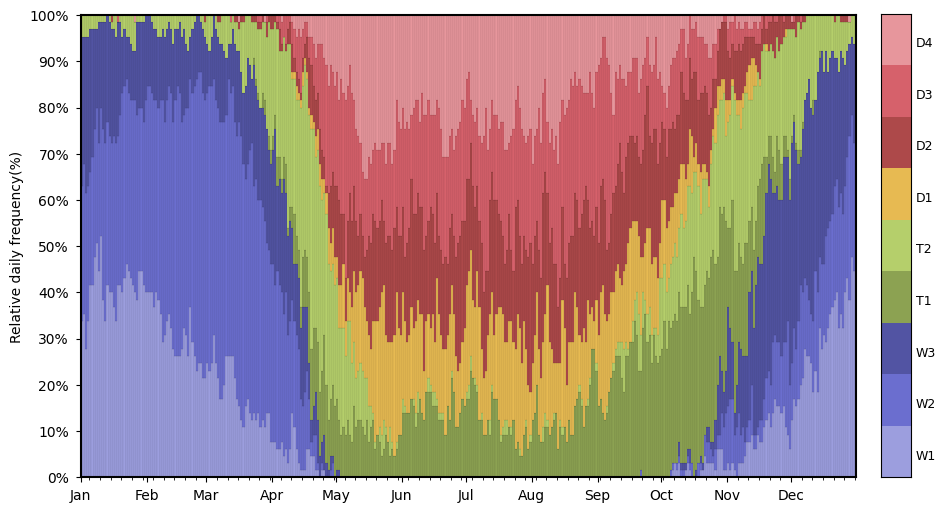

In [36]:
import calendar
conteo=np.zeros((9,365))
#time=pd.date_range(start='01/01/1979',end='12/31/1979',freq='D')

ncps = cps.reshape(-1,365)
for i in range(np.size(conteo,0)):#9
    matBool = ncps==(i+1) #matriz booleana con informacion de los dias del CP i
    for j in range(np.size(conteo,1)):#365
        s=np.sum(matBool[:,j]) #suma sobre los 42 años para el mismo dia j
        s=s/np.size(ncps,0)
        conteo[i,j]=s
        
from matplotlib.ticker import MultipleLocator, ScalarFormatter 

dias = np.arange(1, 366)  # Un array con los días del mes

# Apilamos las frecuencias en un array 2D
frecuencias = conteo #np.vstack([cp1, cp2, cp3,cp4,cp5,cp6,cp7,cp8,cp9])

fig, ax = plt.subplots(figsize=(10,6))

# Usamos la función bar para crear barras apiladas
bottom = np.zeros_like(dias, dtype=float)
colors = plt.colormaps['Set3'](np.linspace(0.2, 0.9, frecuencias.shape[0]))  # Paleta de colores
custom_colors = ['#9c9ede','#6b6ecf','#5254a3','#8ca252','#b5cf6b','#e7ba52','#ad494a','#d6616b','#e7969c']
CP_names = ['W1','W2','W3','T1','T2','D1','D2','D3','D4']
valores = np.arange(0,1.1,1/9)

for i in range(frecuencias.shape[0]):
    ax.bar(dias, frecuencias[i], label=f'{CP_names[i]}', bottom=bottom, width=1,
           color=custom_colors[i],alpha=1, align='edge', linewidth=0.05,edgecolor='black')
    bottom += frecuencias[i]
    
ax.xaxis.set_minor_locator(MultipleLocator(5)) 
ax.xaxis.set_minor_formatter(ScalarFormatter())
ax.tick_params(axis ='both', which ='minor', labelsize = 1, colors ='black', labelcolor='white')
# Configuración para mostrar los meses en el eje x
posMonth = np.array([1, 31,28,31,30,31,30,31,31,30,31,30])
month_names = [calendar.month_abbr[i] for i in range(1, 13)]  # Obtener nombres de los meses
ax.set_xticks(np.cumsum(posMonth))  # Establecer ubicación de los ticks mensuales
ax.set_xticklabels(month_names)  # Establecer etiquetas de los ticks como nombres de los meses
ax.tick_params(axis ='both', which ='major', labelsize = 10, pad = 5, colors ='black')

yticks = np.linspace(0, 1, 11)  # Puedes ajustar los límites y el paso según tus necesidades
ax.set_yticks(yticks)
ax.set_yticklabels(['{:,.0%}'.format(x) for x in ax.get_yticks()])

# Crear la barra grande de la leyenda
legend_labels = [f'CP-{str(i)}' for i in range(frecuencias.shape[0])]

ax.set_xlim(1, 365.5)
ax.set_ylabel("Relative daily frequency(%)")
#ax.legend(loc='upper left', bbox_to_anchor=(1, 1.015), frameon=False)
for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        
# AÑADO BARRA DE CPs

pos = ax.get_position()

left, bottom, width, height = .8, -0.0005,0.03, 0.773 # Ajusta estos valores según sea necesario
newaxs = fig.add_axes([pos.x0 + left, pos.y0 + bottom, width, height])
nn = newaxs.twinx()

for i in range(9):
    nn.bar(1,valores[9-i], color=custom_colors[8-i])


nn.set_yticks(valores[:-1:]+0.05)
nn.set_yticklabels(['W1','W2','W3','T1','T2','D1','D2','D3','D4'])
nn.set_ylim(0,1)
nn.tick_params(length=0.1, labelsize=9)

newaxs.set_xticks([])
newaxs.set_yticks([])
newaxs.set_xlim(0.8,1.2)

for spine in newaxs.spines.values():
        spine.set_linewidth(.5)

#plt.title("Frecuencias relativas CPs a 200hPa - NV")
#plt.savefig(os.path.join('figures','PaperFig','2.1Frequency_CPs_200_1979_2022.2.png'),bbox_inches='tight',pad_inches=0.1, dpi=350)
plt.show()